# Speech Emotion Recognition using TESS Dataset

This notebook demonstrates a complete workflow for Speech Emotion Recognition (SER) using the Toronto Emotional Speech Set (TESS) dataset. The process covers data loading, exploration, preprocessing (MFCC extraction), model building (CNN and LSTM), training, evaluation, and prediction.


## Setup: Install and Import Libraries

First, we'll install the necessary Python libraries for audio processing, machine learning, and visualization. Then, we'll import them to make them available for use in our project.

In [24]:
# Install necessary libraries
!pip install librosa soundfile scikit-learn tensorflow keras matplotlib seaborn


In [25]:
# Import libraries
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully.")


Libraries imported successfully.


## Data Loading and Inspection

We will now locate the TESS dataset files within the `/content/` directory, which is where files uploaded directly to Colab are stored. We'll then create a DataFrame containing the file paths and extract emotion labels from the filenames.

In [26]:
# --- Automatically find the TESS dataset ---

tess_audio_files = []
base_path = '/content/'

# Walk through the /content/ directory to find all .wav files
for root, _, files in os.walk(base_path):
    for file in files:
        full_path = os.path.join(root, file)
        # Check if it's a WAV file and matches the TESS naming convention
        # TESS files typically start with 'YAF_' or 'OAF_' and end with an emotion before .wav
        # Example: YAF_base_sad.wav, OAF_back_fear.wav
        if full_path.endswith('.wav'):
            # Extract relevant part of the filename for emotion and speaker ID
            file_name_stem = os.path.basename(full_path).lower().replace('.wav', '')

            # Simple check for TESS file pattern (YAF/OAF prefix)
            if file_name_stem.startswith('yaf_') or file_name_stem.startswith('oaf_'):
                # Further heuristic check: TESS filenames usually have at least two underscores (e.g., SPEAKER_WORD_EMOTION.wav)
                if file_name_stem.count('_') >= 2:
                    tess_audio_files.append(full_path)

# Ensure no duplicate paths if os.walk visited them multiple ways (unlikely but safe)
tess_audio_files = sorted(list(set(tess_audio_files)))

# Check if files were found
if not tess_audio_files:
    raise FileNotFoundError("No TESS dataset audio files (.wav) matching 'YAF_' or 'OAF_' patterns (e.g., YAF_base_sad.wav) found in /content/ or its subdirectories. Please ensure the dataset is uploaded correctly.")

print(f"Found {len(tess_audio_files)} TESS audio files.")

# Create a DataFrame to store file paths and labels
data = []
for file_path in tqdm(tess_audio_files, desc="Extracting labels"):
    # Example filename format: YAF_base_sad.wav, OAF_back_fear.wav
    # The emotion label is the last part before '.wav'
    file_name = os.path.basename(file_path)
    # Split by underscore and take the last element, then remove '.wav'
    emotion = file_name.split('_')[-1].replace('.wav', '')

    data.append({'file_path': file_path, 'emotion': emotion})

df = pd.DataFrame(data)

# Map specific emotions to standard labels if necessary (e.g., 'disgust' to 'angry')
# TESS dataset contains 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'
# Ensure consistency with common SER emotion sets if needed. Here we keep as is.

print("\nDataFrame head:")
display(df.head())
print("\nEmotion distribution:")
display(df['emotion'].value_counts())


Found 2799 TESS audio files.


Extracting labels: 100%|██████████| 2799/2799 [00:00<00:00, 439217.96it/s]


DataFrame head:


,file_path,emotion
0,/content/OAF_back_angry.wav,angry
1,/content/OAF_back_disgust.wav,disgust
2,/content/OAF_back_fear.wav,fear
3,/content/OAF_back_happy.wav,happy
4,/content/OAF_back_neutral.wav,neutral



Emotion distribution:


,count
emotion,
angry,400
disgust,400
fear,400
happy,400
ps,400
sad,400
neutral,399


## Dataset Verification and Audio Properties

We will perform basic checks on the dataset, such as looking for missing values or duplicates. Then, we'll extract and analyze audio properties like sample rate, duration, and number of channels for each file, adding this information to our DataFrame.

In [27]:
# Dataset verification
print("\nDataFrame Info:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate file paths:")
duplicates = df[df.duplicated('file_path')]
print(f"Number of duplicate file paths: {len(duplicates)}")
if not duplicates.empty:
    print("Displaying duplicates:")
    display(duplicates)

# --- Extract audio properties ---
def extract_audio_properties(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None) # Load with original sample rate
        duration = librosa.get_duration(y=y, sr=sr)
        num_channels = y.shape[0] if y.ndim > 1 else 1
        return pd.Series({'sample_rate': sr, 'duration': duration, 'num_channels': num_channels})
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return pd.Series({'sample_rate': np.nan, 'duration': np.nan, 'num_channels': np.nan})

print("\nExtracting audio properties...")
df = pd.concat([df, df['file_path'].apply(extract_audio_properties)], axis=1)

print("\nDataFrame with audio properties:")
display(df.head())

print("\nSummary of audio properties:")
display(df[['sample_rate', 'duration', 'num_channels']].describe())



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2799 entries, 0 to 2798
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_path  2799 non-null   object
 1   emotion    2799 non-null   object
dtypes: object(2)
memory usage: 43.9+ KB


None


Missing values:


,0
file_path,0
emotion,0



Duplicate file paths:
Number of duplicate file paths: 0

Extracting audio properties...

DataFrame with audio properties:


,file_path,emotion,sample_rate,duration,num_channels
0,/content/OAF_back_angry.wav,angry,24414.0,1.539035,1.0
1,/content/OAF_back_disgust.wav,disgust,24414.0,2.260342,1.0
2,/content/OAF_back_fear.wav,fear,24414.0,1.727124,1.0
3,/content/OAF_back_happy.wav,happy,24414.0,2.000942,1.0
4,/content/OAF_back_neutral.wav,neutral,24414.0,2.043418,1.0



Summary of audio properties:


,sample_rate,duration,num_channels
count,2799.000000,2799.000000,2799.0
mean,24439.575563,2.055105,1.0
std,1353.089883,0.320862,0.0
min,24414.000000,1.254076,1.0
25%,24414.000000,1.836385,1.0
50%,24414.000000,2.047514,1.0
75%,24414.000000,2.277648,1.0
max,96000.000000,2.984804,1.0


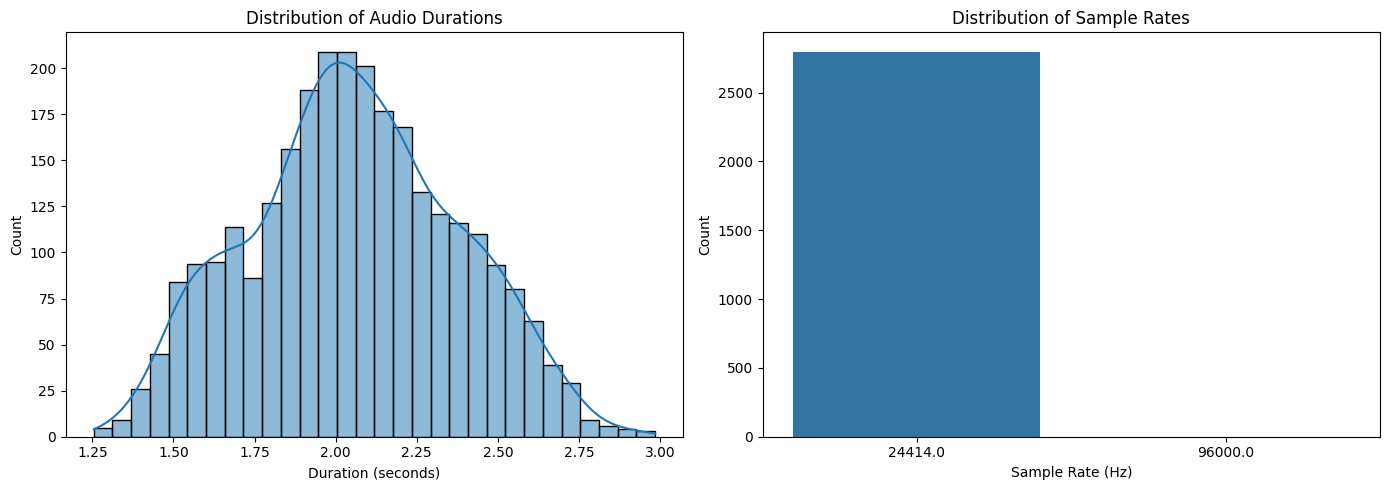

In [28]:
# Visualize audio properties
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['duration'], bins=30, kde=True)
plt.title('Distribution of Audio Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='sample_rate', data=df)
plt.title('Distribution of Sample Rates')
plt.xlabel('Sample Rate (Hz)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


## Waveform Visualization

To understand the raw audio data, we will visualize the waveforms of a few sample audio files, picking one from each emotion category if available. This helps in visually inspecting amplitude variations over time.

Visualizing waveforms for one sample from each emotion:


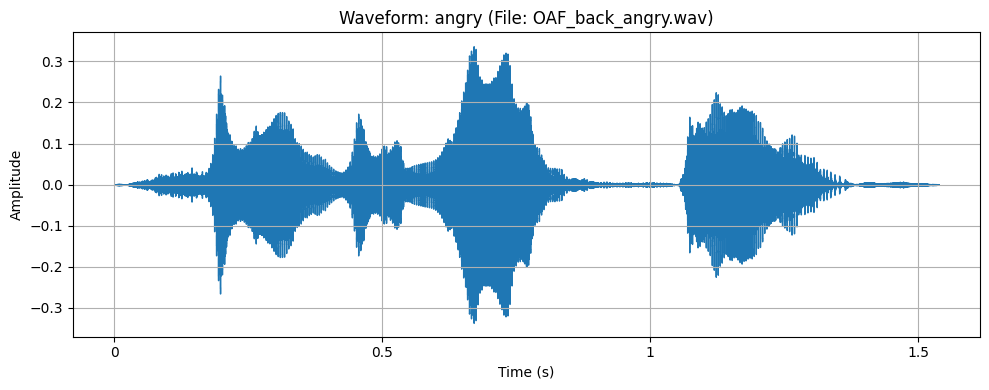

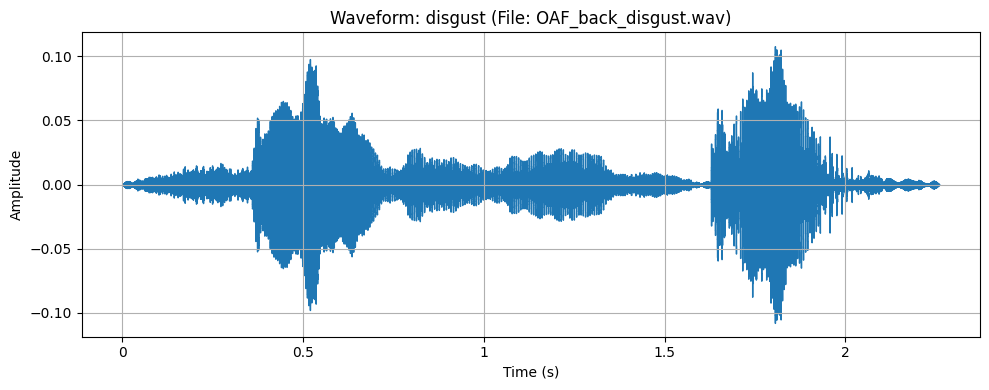

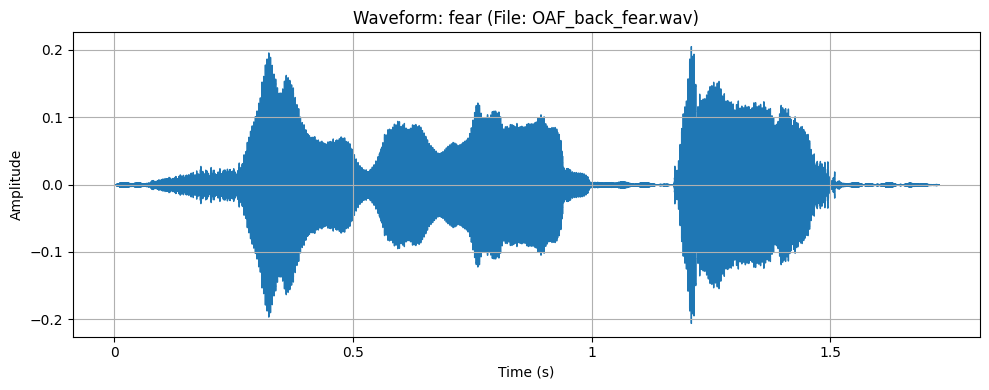

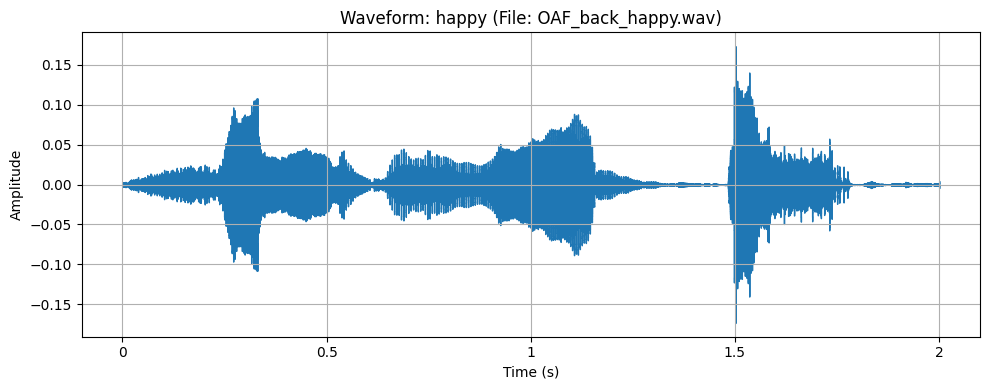

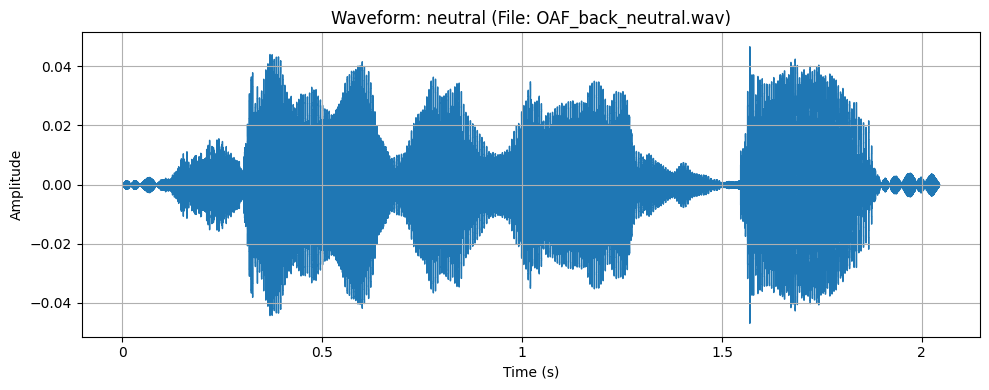

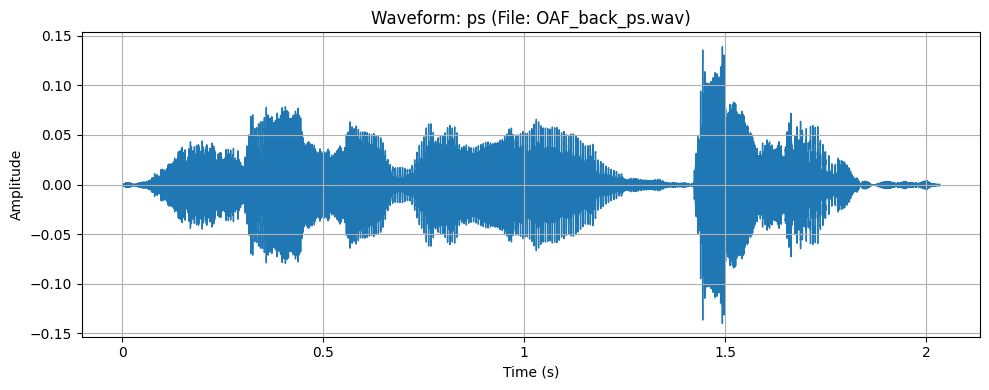

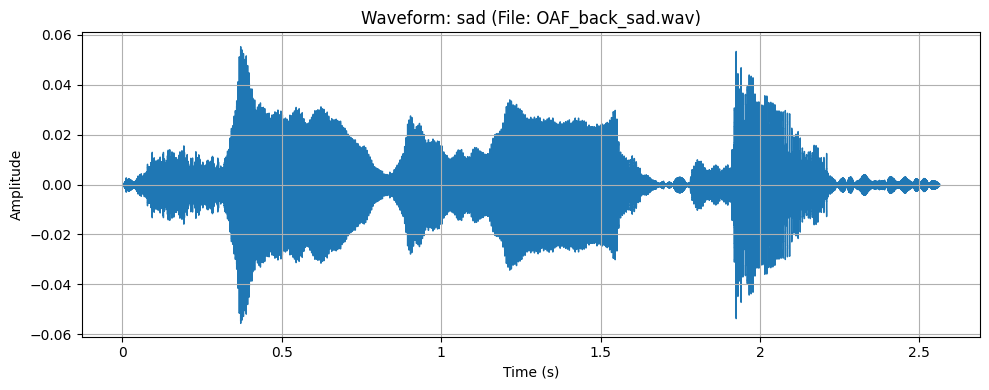

In [29]:
# Waveform visualization for sample audio files

def plot_waveform(file_path, emotion, sr=None):
    try:
        y, sr = librosa.load(file_path, sr=sr) # Load with default sr or specified
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.title(f'Waveform: {emotion} (File: {os.path.basename(file_path)})')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting waveform for {file_path}: {e}")

# Get one sample from each emotion category for visualization
sample_files = df.groupby('emotion').first().reset_index()

print("Visualizing waveforms for one sample from each emotion:")
for _, row in sample_files.iterrows():
    plot_waveform(row['file_path'], row['emotion'])


## Preprocessing: MFCC Extraction and Label Encoding

This section focuses on preparing the audio data for machine learning models. We will define functions for loading and preprocessing audio, and for extracting Mel-Frequency Cepstral Coefficients (MFCCs). MFCCs are a widely used feature in speech recognition. Finally, we'll encode our categorical emotion labels into numerical format.

In [30]:
# Preprocessing function: Load audio, resample, and normalize
def preprocess_audio(file_path, target_sr=22050):
    try:
        y, sr = librosa.load(file_path, sr=target_sr, duration=3.0) # Load first 3 seconds, resample
        y = librosa.util.normalize(y) # Normalize amplitude
        return y
    except Exception as e:
        print(f"Error loading/preprocessing {file_path}: {e}")
        return None

# MFCC extraction function
def extract_mfccs(audio_data, sr, n_mfcc=40, max_len=150):
    if audio_data is None:
        return None
    mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=n_mfcc)

    # Pad or truncate MFCCs to a fixed length
    if mfccs.shape[1] > max_len:
        mfccs = mfccs[:, :max_len]
    else:
        pad_width = max_len - mfccs.shape[1]
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    return mfccs

# Apply preprocessing and MFCC extraction
features = []
labels = []

TARGET_SR = 22050 # Common sample rate for speech
N_MFCC = 40       # Number of MFCCs to extract
MAX_MFCC_LEN = 150 # Fixed length for MFCC sequences

print(f"Extracting MFCCs (n_mfcc={N_MFCC}, max_len={MAX_MFCC_LEN}) from audio files...")
for index, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio"):
    audio = preprocess_audio(row['file_path'], target_sr=TARGET_SR)
    if audio is not None:
        mfccs = extract_mfccs(audio, sr=TARGET_SR, n_mfcc=N_MFCC, max_len=MAX_MFCC_LEN)
        if mfccs is not None:
            features.append(mfccs)
            labels.append(row['emotion'])

# Convert to numpy arrays
X = np.array(features)
y = np.array(labels)

print(f"\nShape of extracted features (X): {X.shape}") # Expected: (num_samples, n_mfcc, max_mfcc_len)
print(f"Shape of labels (y): {y.shape}")


Extracting MFCCs (n_mfcc=40, max_len=150) from audio files...


Processing audio: 100%|██████████| 2799/2799 [00:55<00:00, 50.28it/s]



Shape of extracted features (X): (2799, 40, 150)
Shape of labels (y): (2799,)


In [31]:
# Label Encoding for emotion labels

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded) # One-hot encode for Keras models

print("Original labels:", np.unique(y))
print("Encoded labels:", encoder.classes_)
print("Shape of one-hot encoded labels (y_categorical):", y_categorical.shape)

# Store encoded classes for later use
num_classes = len(encoder.classes_)
print(f"Number of classes: {num_classes}")


Original labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']
Encoded labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']
Shape of one-hot encoded labels (y_categorical): (2799, 7)
Number of classes: 7


## Data Splitting and Reshaping

We will now split our dataset into training, validation, and test sets. A stratified split ensures that each set maintains the same proportion of emotion classes as the original dataset. For the Convolutional Neural Network (CNN) model, the MFCC features will be reshaped to include a channel dimension.

In [32]:
# Stratified Train/Validation/Test Split

# First, split into train and test (80/20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Then, split train_val into train and validation (80/20 of the 80%, i.e., 64/16/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=np.argmax(y_train_val, axis=1)
) # Use argmax to get original encoded labels for stratification

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Reshape MFCC data for CNN (add channel dimension: samples, features, time, channels)
# For Conv1D, input shape is (batch_size, timesteps, features)
# Our MFCCs are (num_samples, n_mfcc, max_len) -> (num_samples, max_len, n_mfcc) if time is the primary dimension
# Let's consider `max_len` as timesteps and `n_mfcc` as features for Conv1D

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[2], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[2], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[2], X_test.shape[1], 1)

print(f"\nReshaped X_train for CNN: {X_train_cnn.shape}")
print(f"Reshaped X_val for CNN: {X_val_cnn.shape}")
print(f"Reshaped X_test for CNN: {X_test_cnn.shape}")

# For LSTM, input shape is (batch_size, timesteps, features)
# Our MFCCs are (num_samples, n_mfcc, max_len). We can treat max_len as timesteps and n_mfcc as features.
X_train_lstm = X_train.transpose(0, 2, 1) # (num_samples, max_len, n_mfcc)
X_val_lstm = X_val.transpose(0, 2, 1)
X_test_lstm = X_test.transpose(0, 2, 1)

print(f"\nReshaped X_train for LSTM: {X_train_lstm.shape}")
print(f"Reshaped X_val for LSTM: {X_val_lstm.shape}")
print(f"Reshaped X_test for LSTM: {X_test_lstm.shape}")


X_train shape: (1679, 40, 150), y_train shape: (1679, 7)
X_val shape: (560, 40, 150), y_val shape: (560, 7)
X_test shape: (560, 40, 150), y_test shape: (560, 7)

Reshaped X_train for CNN: (1679, 150, 40, 1)
Reshaped X_val for CNN: (560, 150, 40, 1)
Reshaped X_test for CNN: (560, 150, 40, 1)

Reshaped X_train for LSTM: (1679, 150, 40)
Reshaped X_val for LSTM: (560, 150, 40)
Reshaped X_test for LSTM: (560, 150, 40)


Found 2799 TESS audio files.


Extracting labels: 100%|██████████| 2799/2799 [00:00<00:00, 506290.19it/s]


DataFrame head:


,file_path,emotion
0,/content/OAF_back_angry.wav,angry
1,/content/OAF_back_disgust.wav,disgust
2,/content/OAF_back_fear.wav,fear
3,/content/OAF_back_happy.wav,happy
4,/content/OAF_back_neutral.wav,neutral



Emotion distribution:


...

,0
file_path,0
emotion,0



Duplicate file paths:
Number of duplicate file paths: 0

Extracting audio properties...

DataFrame with audio properties:


,file_path,emotion,sample_rate,duration,num_channels
0,/content/OAF_back_angry.wav,angry,24414.0,1.539035,1.0
1,/content/OAF_back_disgust.wav,disgust,24414.0,2.260342,1.0
2,/content/OAF_back_fear.wav,fear,24414.0,1.727124,1.0
3,/content/OAF_back_happy.wav,happy,24414.0,2.000942,1.0
4,/content/OAF_back_neutral.wav,neutral,24414.0,2.043418,1.0



Summary of audio properties:


,sample_rate,duration,num_channels
count,2799.000000,2799.000000,2799.0
mean,24439.575563,2.055105,1.0
std,1353.089883,0.320862,0.0
min,24414.000000,1.254076,1.0
25%,24414.000000,1.836385,1.0
50%,24414.000000,2.047514,1.0
75%,24414.000000,2.277648,1.0
max,96000.000000,2.984804,1.0


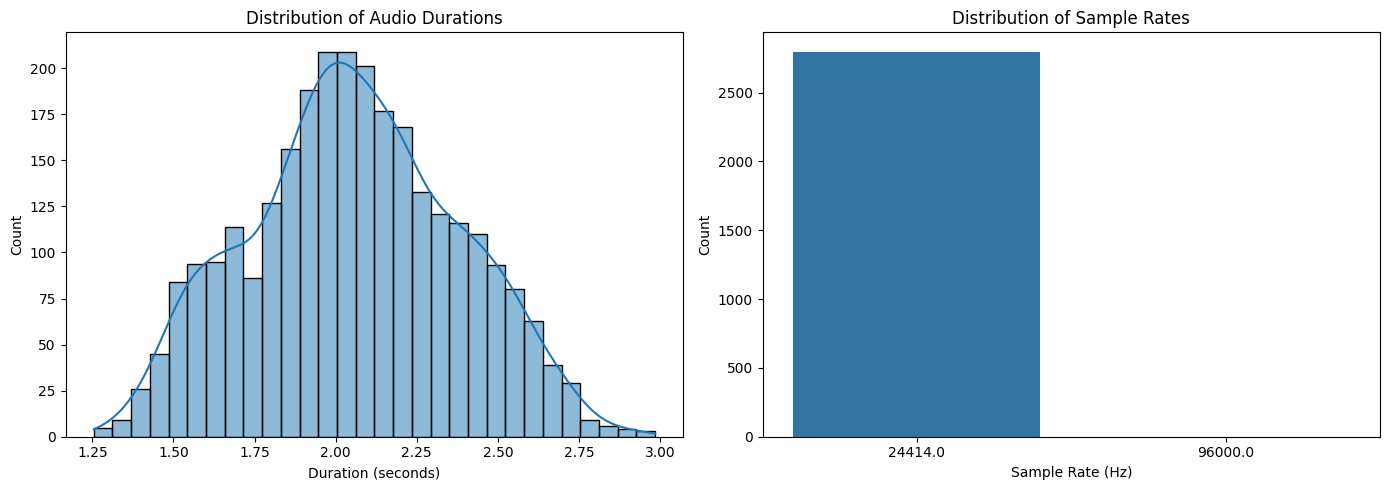

Visualizing waveforms for one sample from each emotion:


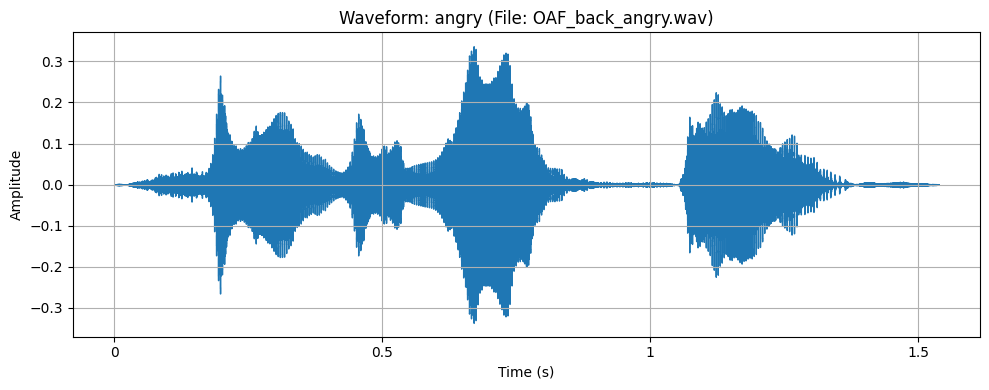

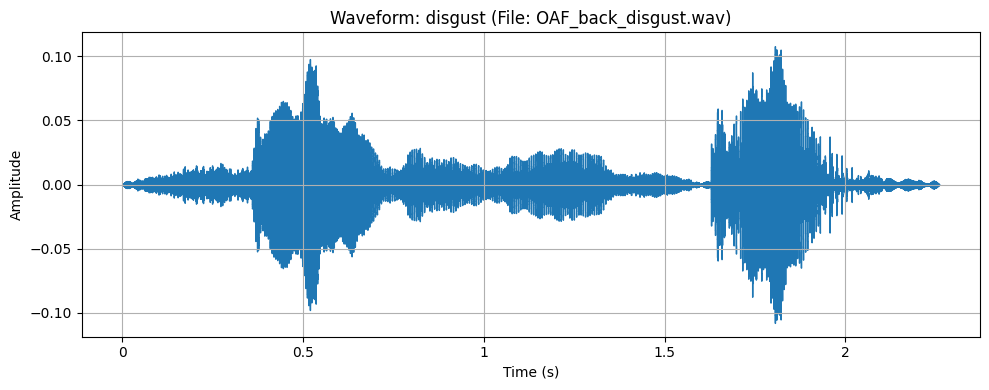

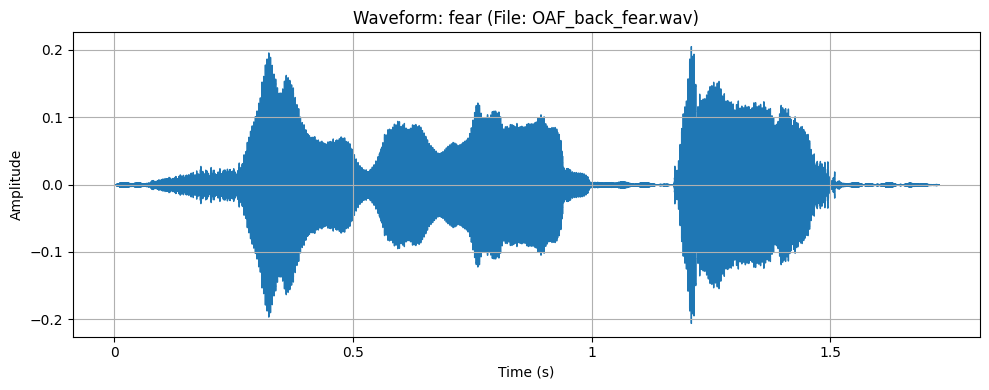

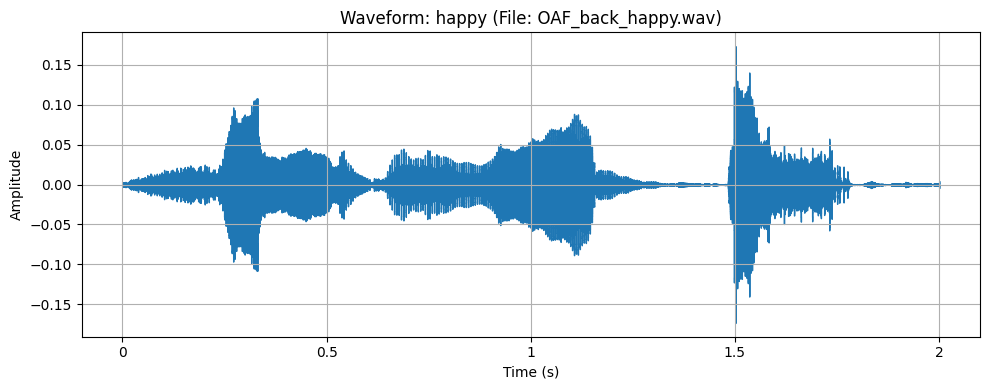

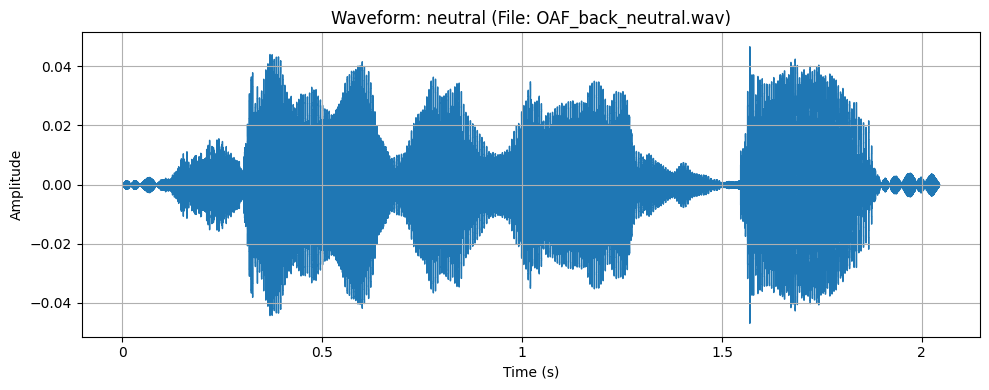

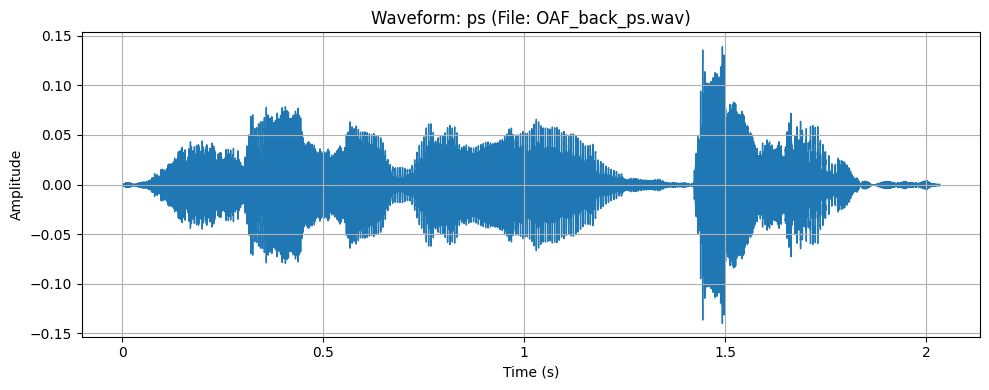

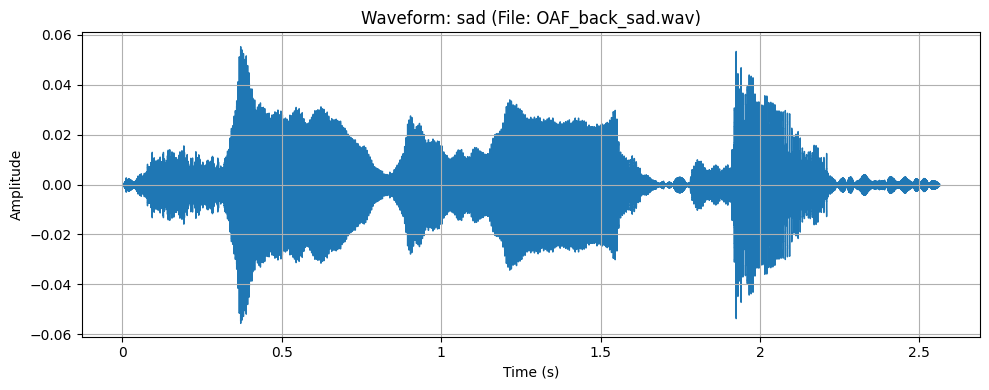

Extracting MFCCs (n_mfcc=40, max_len=150) from audio files...


Processing audio: 100%|██████████| 2799/2799 [00:50<00:00, 55.04it/s]



Shape of extracted features (X): (2799, 40, 150)
Shape of labels (y): (2799,)
Original labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']
Encoded labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']
Shape of one-hot encoded labels (y_categorical): (2799, 7)
Number of classes: 7
X_train shape: (1679, 40, 150), y_train shape: (1679, 7)
X_val shape: (560, 40, 150), y_val shape: (560, 7)
X_test shape: (560, 40, 150), y_test shape: (560, 7)

Reshaped X_train for CNN: (1679, 150, 40, 1)
Reshaped X_val for CNN: (560, 150, 40, 1)
Reshaped X_test for CNN: (560, 150, 40, 1)

Reshaped X_train for LSTM: (1679, 150, 40)
Reshaped X_val for LSTM: (560, 150, 40)
Reshaped X_test for LSTM: (560, 150, 40)


In [33]:
# Consolidated Data Preparation Pipeline (replacing previous %exec_cell calls)

# --- Automatically find the TESS dataset (from 43b56d4b) ---
tess_audio_files = []
base_path = '/content/'

# Walk through the /content/ directory to find all .wav files
for root, _, files in os.walk(base_path):
    for file in files:
        full_path = os.path.join(root, file)
        # Check if it's a WAV file and matches the TESS naming convention
        # TESS files typically start with 'YAF_' or 'OAF_' and end with an emotion before .wav
        # Example: YAF_base_sad.wav, OAF_back_fear.wav
        if full_path.endswith('.wav'):
            # Extract relevant part of the filename for emotion and speaker ID
            file_name_stem = os.path.basename(full_path).lower().replace('.wav', '')

            # Simple check for TESS file pattern (YAF/OAF prefix)
            if file_name_stem.startswith('yaf_') or file_name_stem.startswith('oaf_'):
                # Further heuristic check: TESS filenames usually have at least two underscores (e.g., SPEAKER_WORD_EMOTION.wav)
                if file_name_stem.count('_') >= 2:
                    tess_audio_files.append(full_path)

# Ensure no duplicate paths if os.walk visited them multiple ways (unlikely but safe)
tess_audio_files = sorted(list(set(tess_audio_files)))

# Check if files were found
if not tess_audio_files:
    raise FileNotFoundError("No TESS dataset audio files (.wav) matching 'YAF_' or 'OAF_' patterns (e.g., YAF_base_sad.wav) found in /content/ or its subdirectories. Please ensure the dataset is uploaded correctly.")

print(f"Found {len(tess_audio_files)} TESS audio files.")

# Create a DataFrame to store file paths and labels
data = []
for file_path in tqdm(tess_audio_files, desc="Extracting labels"):
    # Example filename format: YAF_base_sad.wav, OAF_back_fear.wav
    # The emotion label is the last part before '.wav'
    file_name = os.path.basename(file_path)
    # Split by underscore and take the last element, then remove '.wav'
    emotion = file_name.split('_')[-1].replace('.wav', '')

    data.append({'file_path': file_path, 'emotion': emotion})

df = pd.DataFrame(data)

# Map specific emotions to standard labels if necessary (e.g., 'disgust' to 'angry')
# TESS dataset contains 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'
# Ensure consistency with common SER emotion sets if needed. Here we keep as is.

print("\nDataFrame head:")
display(df.head())
print("\nEmotion distribution:")
display(df['emotion'].value_counts())

# --- Dataset verification and audio properties (from eea2b8fc) ---
print("\nDataFrame Info:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate file paths:")
duplicates = df[df.duplicated('file_path')]
print(f"Number of duplicate file paths: {len(duplicates)}")
if not duplicates.empty:
    print("Displaying duplicates:")
    display(duplicates)

# --- Extract audio properties ---
def extract_audio_properties(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None) # Load with original sample rate
        duration = librosa.get_duration(y=y, sr=sr)
        num_channels = y.shape[0] if y.ndim > 1 else 1
        return pd.Series({'sample_rate': sr, 'duration': duration, 'num_channels': num_channels})
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return pd.Series({'sample_rate': np.nan, 'duration': np.nan, 'num_channels': np.nan})

print("\nExtracting audio properties...")
df = pd.concat([df, df['file_path'].apply(extract_audio_properties)], axis=1)

print("\nDataFrame with audio properties:")
display(df.head())

print("\nSummary of audio properties:")
display(df[['sample_rate', 'duration', 'num_channels']].describe())

# --- Visualize audio properties (from 84a8ffff) ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['duration'], bins=30, kde=True)
plt.title('Distribution of Audio Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='sample_rate', data=df)
plt.title('Distribution of Sample Rates')
plt.xlabel('Sample Rate (Hz)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# --- Waveform visualization (from 92f12e75) ---
# Waveform visualization for sample audio files

def plot_waveform(file_path, emotion, sr=None):
    try:
        y, sr = librosa.load(file_path, sr=sr) # Load with default sr or specified
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.title(f'Waveform: {emotion} (File: {os.path.basename(file_path)})')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting waveform for {file_path}: {e}")

# Get one sample from each emotion category for visualization
sample_files = df.groupby('emotion').first().reset_index()

print("Visualizing waveforms for one sample from each emotion:")
for _, row in sample_files.iterrows():
    plot_waveform(row['file_path'], row['emotion'])

# --- Preprocessing: MFCC Extraction and Label Encoding (from 80b29c2d) ---
# Preprocessing function: Load audio, resample, and normalize
def preprocess_audio(file_path, target_sr=22050):
    try:
        y, sr = librosa.load(file_path, sr=target_sr, duration=3.0) # Load first 3 seconds, resample
        y = librosa.util.normalize(y) # Normalize amplitude
        return y
    except Exception as e:
        print(f"Error loading/preprocessing {file_path}: {e}")
        return None

# MFCC extraction function
def extract_mfccs(audio_data, sr, n_mfcc=40, max_len=150):
    if audio_data is None:
        return None
    mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=n_mfcc)

    # Pad or truncate MFCCs to a fixed length
    if mfccs.shape[1] > max_len:
        mfccs = mfccs[:, :max_len]
    else:
        pad_width = max_len - mfccs.shape[1]
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    return mfccs

# Apply preprocessing and MFCC extraction
features = []
labels = []

TARGET_SR = 22050 # Common sample rate for speech
N_MFCC = 40       # Number of MFCCs to extract
MAX_MFCC_LEN = 150 # Fixed length for MFCC sequences

print(f"Extracting MFCCs (n_mfcc={N_MFCC}, max_len={MAX_MFCC_LEN}) from audio files...")
for index, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio"):
    audio = preprocess_audio(row['file_path'], target_sr=TARGET_SR)
    if audio is not None:
        mfccs = extract_mfccs(audio, sr=TARGET_SR, n_mfcc=N_MFCC, max_len=MAX_MFCC_LEN)
        if mfccs is not None:
            features.append(mfccs)
            labels.append(row['emotion'])

# Convert to numpy arrays
X = np.array(features)
y = np.array(labels)

print(f"\nShape of extracted features (X): {X.shape}") # Expected: (num_samples, n_mfcc, max_mfcc_len)
print(f"Shape of labels (y): {y.shape}")

# --- Label Encoding for emotion labels (from 2c1e88cf) ---
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded) # One-hot encode for Keras models

print("Original labels:", np.unique(y))
print("Encoded labels:", encoder.classes_)
print("Shape of one-hot encoded labels (y_categorical):", y_categorical.shape)

# Store encoded classes for later use
num_classes = len(encoder.classes_)
print(f"Number of classes: {num_classes}")

# --- Data Splitting and Reshaping (from b719b4dc) ---
# Stratified Train/Validation/Test Split

# First, split into train and test (80/20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Then, split train_val into train and validation (80/20 of the 80%, i.e., 64/16/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=np.argmax(y_train_val, axis=1)
) # Use argmax to get original encoded labels for stratification

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Reshape MFCC data for CNN (add channel dimension: samples, features, time, channels)
# For Conv1D, input shape is (batch_size, timesteps, features)
# Our MFCCs are (num_samples, n_mfcc, max_len) -> (num_samples, max_len, n_mfcc) if time is the primary dimension
# Let's consider `max_len` as timesteps and `n_mfcc` as features for Conv1D

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[2], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[2], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[2], X_test.shape[1], 1)

print(f"\nReshaped X_train for CNN: {X_train_cnn.shape}")
print(f"Reshaped X_val for CNN: {X_val_cnn.shape}")
print(f"Reshaped X_test for CNN: {X_test_cnn.shape}")

# For LSTM, input shape is (batch_size, timesteps, features)
# Our MFCCs are (num_samples, n_mfcc, max_len). We can treat max_len as timesteps and n_mfcc as features.
X_train_lstm = X_train.transpose(0, 2, 1) # (num_samples, max_len, n_mfcc)
X_val_lstm = X_val.transpose(0, 2, 1)
X_test_lstm = X_test.transpose(0, 2, 1)

print(f"\nReshaped X_train for LSTM: {X_train_lstm.shape}")
print(f"Reshaped X_val for LSTM: {X_val_lstm.shape}")
print(f"Reshaped X_test for LSTM: {X_test_lstm.shape}")


In [36]:
# The consolidated data preparation pipeline is defined in cell 2a2a61c8. Please run that cell directly to execute it.

## CNN Model Building and Training

We'll construct a Convolutional Neural Network (CNN) model. CNNs are well-suited for learning hierarchical features from grid-like data, such as images or, in this case, MFCC spectrograms. The model will consist of convolutional layers, pooling layers, and dense layers for classification.

In [40]:
# CNN Model Architecture

from tensorflow.keras.layers import Conv2D, MaxPooling2D

# Input shape: (max_len, n_mfcc, 1)
# We reshaped X for CNN to (num_samples, max_len, n_mfcc, 1)
# So input_shape for the model will be (max_len, n_mfcc, 1)

cnn_input_shape = (X_train_cnn.shape[1], X_train_cnn.shape[2], X_train_cnn.shape[3])

cnn_model = Sequential([
    Input(shape=cnn_input_shape), # Explicitly define Input layer as recommended by Keras
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

# Compile the CNN model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("CNN Model Summary:")
cnn_model.summary()

CNN Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 150, 40, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 75, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 75, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 37, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 37, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 18, 5, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 18, 5, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,043,847 (11.61 MB)

 Trainable params: 3,043,847 (11.61 MB)

 Non-trainable params: 0 (0.00 B)

## Feature Scaling for CNN Input

Neural networks, especially those with many layers, often benefit significantly from feature scaling. By standardizing the input features (e.g., to have a mean of 0 and a standard deviation of 1), we ensure that all features contribute equally to the distance calculations and prevent issues where larger-valued features dominate the learning process. This can lead to faster convergence and a more stable training process for the CNN model.

In [41]:
# Apply StandardScaler to CNN input data
scaler = StandardScaler()

# Reshape data to 2D for scaling (samples, features)
# Flatten the (max_len, n_mfcc, 1) part for each sample
X_train_cnn_scaled = scaler.fit_transform(X_train_cnn.reshape(-1, X_train_cnn.shape[2] * X_train_cnn.shape[3]))
X_val_cnn_scaled = scaler.transform(X_val_cnn.reshape(-1, X_val_cnn.shape[2] * X_val_cnn.shape[3]))
X_test_cnn_scaled = scaler.transform(X_test_cnn.reshape(-1, X_test_cnn.shape[2] * X_test_cnn.shape[3]))

# Reshape back to original 4D CNN input shape
X_train_cnn = X_train_cnn_scaled.reshape(X_train_cnn.shape)
X_val_cnn = X_val_cnn_scaled.reshape(X_val_cnn.shape)
X_test_cnn = X_test_cnn_scaled.reshape(X_test_cnn.shape)

print("CNN input features scaled successfully.")
print(f"X_train_cnn (scaled) shape: {X_train_cnn.shape}")

CNN input features scaled successfully.
X_train_cnn (scaled) shape: (1679, 150, 40, 1)


In [42]:
# Train the CNN model

# Define Early Stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

print("\nTraining CNN model...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,           # You might adjust this based on your dataset and model complexity
    batch_size=32,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stopping], # Apply early stopping
    verbose=1
)

print("CNN model training complete.")


Training CNN model...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 789ms/step - accuracy: 0.5968 - loss: 1.0574 - val_accuracy: 0.9375 - val_loss: 0.2269
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 554ms/step - accuracy: 0.9053 - loss: 0.2518 - val_accuracy: 0.9750 - val_loss: 0.0919
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 535ms/step - accuracy: 0.9577 - loss: 0.1252 - val_accuracy: 0.9804 - val_loss: 0.0567
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 547ms/step - accuracy: 0.9649 - loss: 0.1069 - val_accuracy: 0.9839 - val_loss: 0.0452
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 550ms/step - accuracy: 0.9774 - loss: 0.0617 - val_accuracy: 0.9839 - val_loss: 0.0572
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 538ms/step - accuracy: 0.9786 - loss: 0.0644 - val_accuracy: 0.9839 - val_loss: 0.0462
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 547ms/step - accuracy: 0.9797 - loss: 0.0525 - val_accuracy: 0.9893 - val_loss: 0.0358
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 546ms/step - accuracy: 0

## LSTM Model Building and Training

Next, we'll build and train a Long Short-Term Memory (LSTM) network. LSTMs are a type of Recurrent Neural Network (RNN) particularly effective with sequential data, which is ideal for the time-series nature of MFCCs. This model will capture temporal dependencies in the audio features.

In [43]:
# LSTM Model Architecture

# Input shape: (max_len, n_mfcc)
# We reshaped X for LSTM to (num_samples, max_len, n_mfcc)
# So input_shape for the model will be (max_len, n_mfcc)

lstm_input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])

lstm_model = Sequential([
    Input(shape=lstm_input_shape),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile the LSTM model
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("LSTM Model Summary:")
lstm_model.summary()

LSTM Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 150, 128)       │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,391 (532.78 KB)

 Trainable params: 136,391 (532.78 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Train the LSTM model

# Reuse the Early Stopping callback
print("\nTraining LSTM model...")
lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,           # You might adjust this based on your dataset and model complexity
    batch_size=32,
    validation_data=(X_val_lstm, y_val),
    callbacks=[early_stopping], # Apply early stopping
    verbose=1
)

print("LSTM model training complete.")


Training LSTM model...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 361ms/step - accuracy: 0.3002 - loss: 1.5836 - val_accuracy: 0.4357 - val_loss: 1.2799
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 398ms/step - accuracy: 0.5444 - loss: 1.0829 - val_accuracy: 0.5446 - val_loss: 1.0640
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 347ms/step - accuracy: 0.7076 - loss: 0.7349 - val_accuracy: 0.8161 - val_loss: 0.5570
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 325ms/step - accuracy: 0.7641 - loss: 0.6138 - val_accuracy: 0.7018 - val_loss: 0.6914
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 362ms/step - accuracy: 0.7689 - loss: 0.5433 - val_accuracy: 0.8446 - val_loss: 0.3675
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 346ms/step - accuracy: 0.8684 - loss: 0.3107 - val_accuracy: 0.8768 - val_loss: 0.2749
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 326ms/step - accuracy: 0.9005 - loss: 0.2373 - val_accuracy: 0.9143 - val_loss: 0.2611
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 357ms/step - accuracy: 

## Model Training Visualization

We will now visualize the training history (accuracy and loss over epochs) for both the CNN and LSTM models. These plots help us understand how well each model learned and if there are signs of overfitting or underfitting.

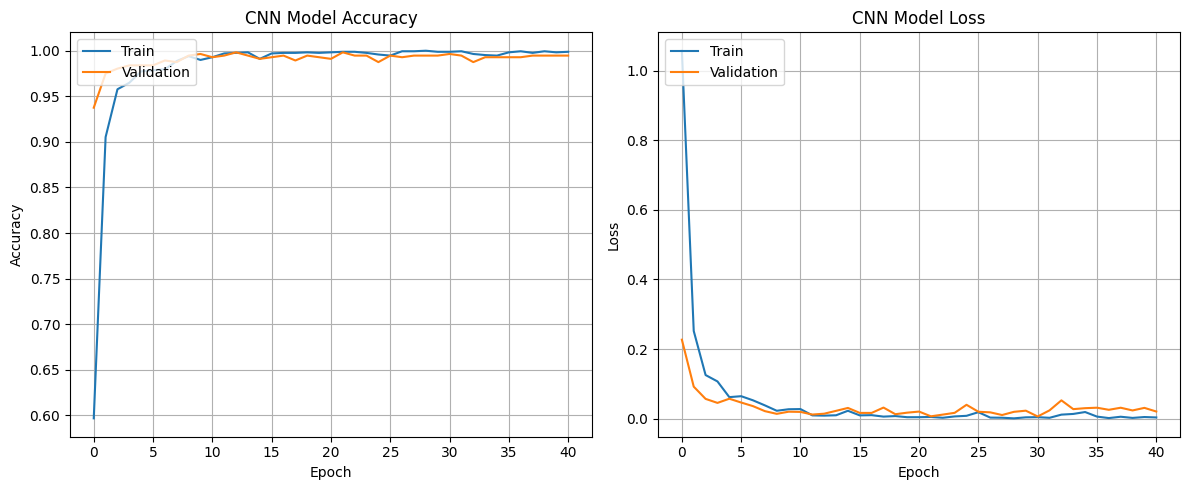

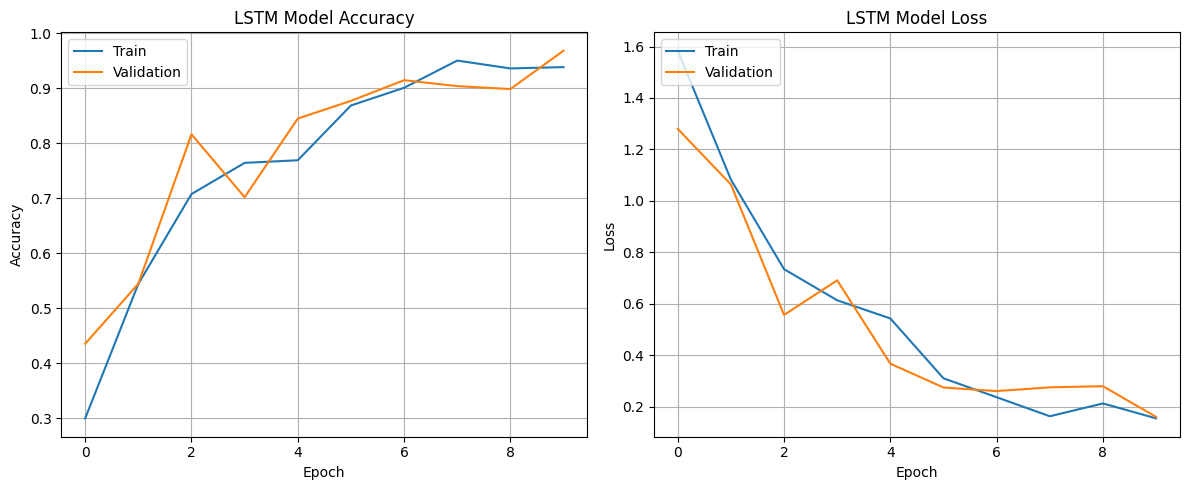

In [48]:
# Plot training history for CNN and LSTM models

def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot history for CNN
plot_training_history(cnn_history, 'CNN')

# Plot history for LSTM
plot_training_history(lstm_history, 'LSTM')